# Correlation between instruments

This example illustrates how to:

- Load data from two different instruments (NanoScan)
- Generate a correlation plot for the two instruments

In [1]:
import matplotlib.pyplot as plt
import aerosoltools as at

## Load the two NS datasets

In [2]:
ns_file1 = r"..\..\tests\data\Combine_example_NS.csv"
ns_file2 = r"..\..\tests\data\Correlation_example_NS2.csv"

ns1 = at.Load_NS_file(ns_file1, extra_data  =True)
ns2 = at.Load_NS_file(ns_file2, extra_data  =True)

## Generate a correlation plot

It is often relevant to consider offsets between two instruments, which is usually done by measuring particle concentrations in parallel for a specific time before experiments. The total concentrations reported by the two instruments are then compared on a time by time basis, to assess their differences in reported particle levels.

(<Figure size 1900x1000 with 1 Axes>, <Axes: xlabel='X: NS', ylabel='Y: NS'>)

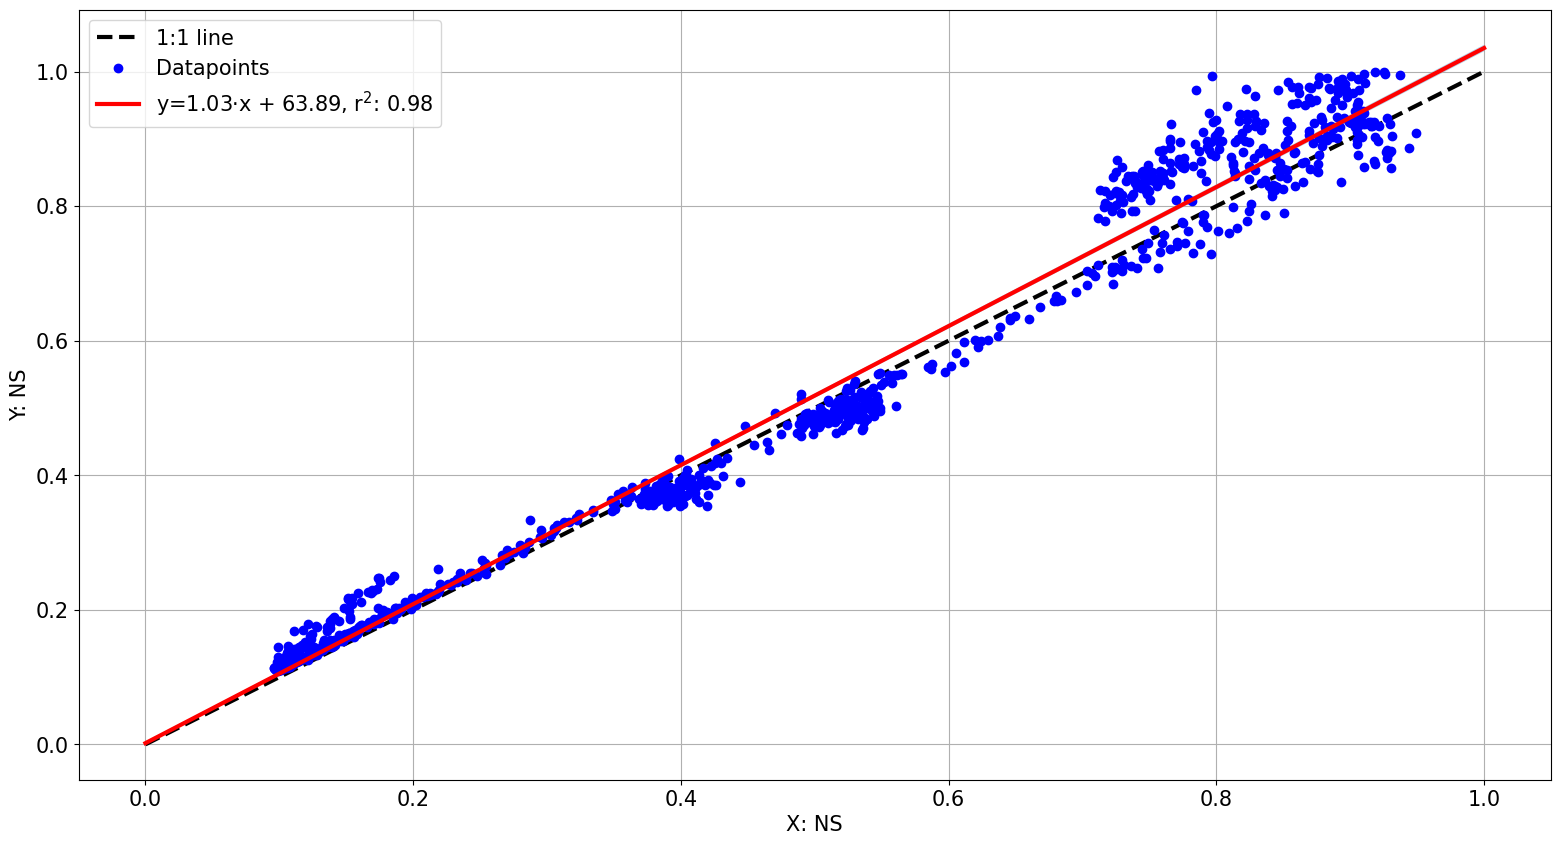

In [3]:
Parallel_measurement_start = "2023-10-23 13:27:00"
Parallel_measurement_end = "2023-10-24 7:00:00"

at.Plot_correlation(ns1,ns2,start_time = Parallel_measurement_start,end_time = Parallel_measurement_end,match="nearest",tolerance="45s")

## Correlating different metrics and with different settings

The `Plot_correlation` function can be used to compare any columns appearing in both datasets for instance a specific size bin, such as "36.5" - as can be found via list(ns1.data), listing all column names in the main data. In addition the fitting procedure can be set to minimize influence from outliers.

In the plot below, the two instruments are matched not only within the parallel measurement period, which is why a less clear correlation is observed.

(<Figure size 1900x1000 with 1 Axes>, <Axes: xlabel='X: NS', ylabel='Y: NS'>)

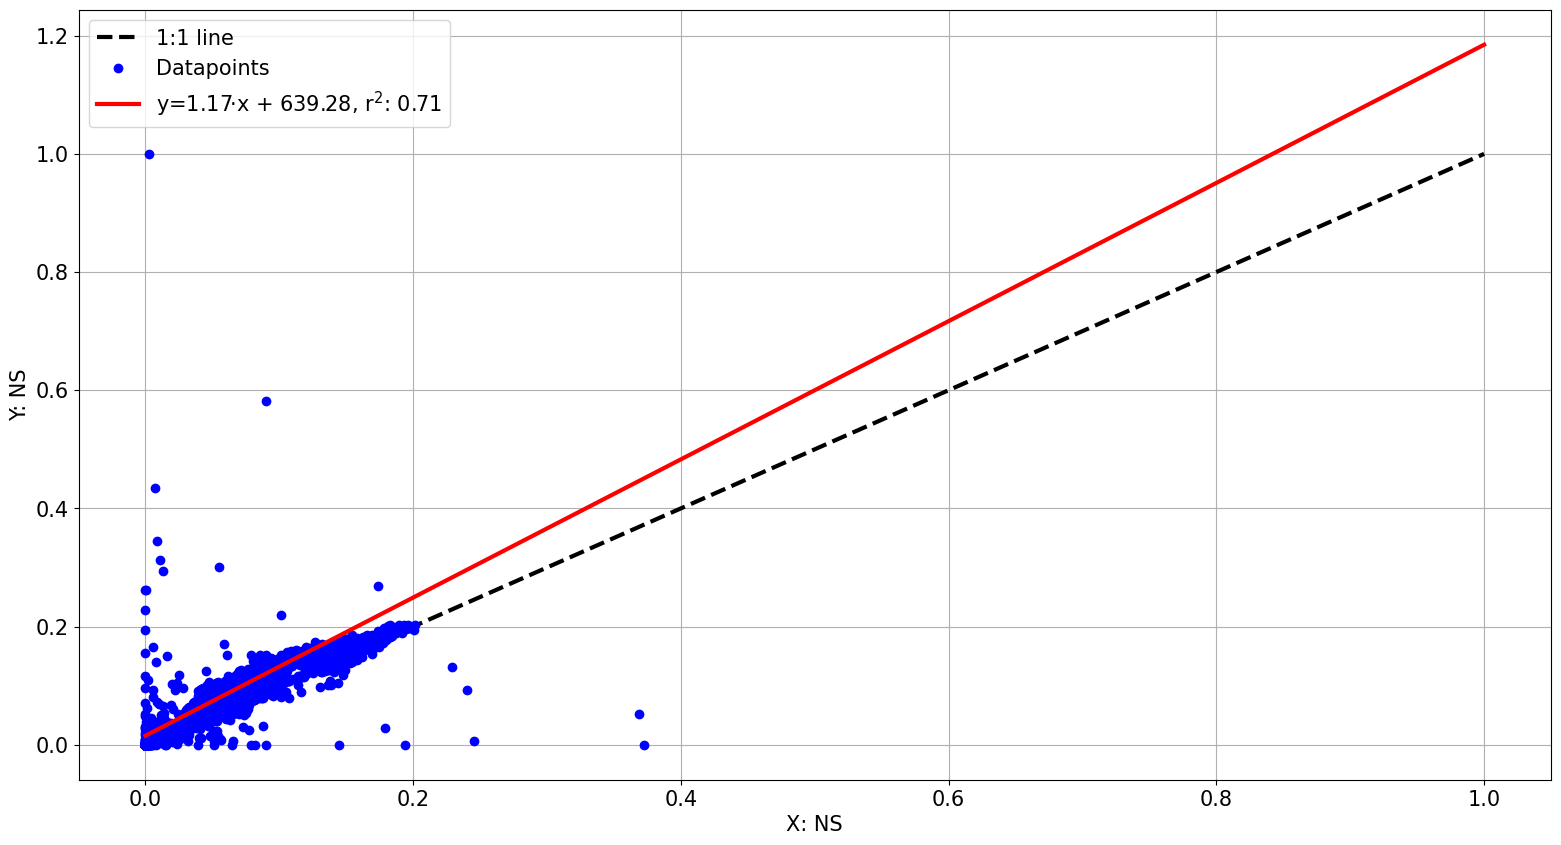

In [6]:
at.Plot_correlation(ns1,ns2,column="36.5",match="nearest",tolerance="45s",intercept=False, outlier_influence=False)

Correlation may also be performed for parameters in the extra_data. The correlation plot will look for column names both in the main DataFrame and in the extra_data Dataframe.

In [13]:
list(ns1.extra_data) # column names in the extra_data

['Median (nm)',
 'Mean (nm)',
 'Geo Mean (nm)',
 'Mode (nm)',
 'GSD',
 'Particle Density (g/cc)',
 'Firmware Version',
 'Status']

(<Figure size 1900x1000 with 1 Axes>, <Axes: xlabel='X: NS', ylabel='Y: NS'>)

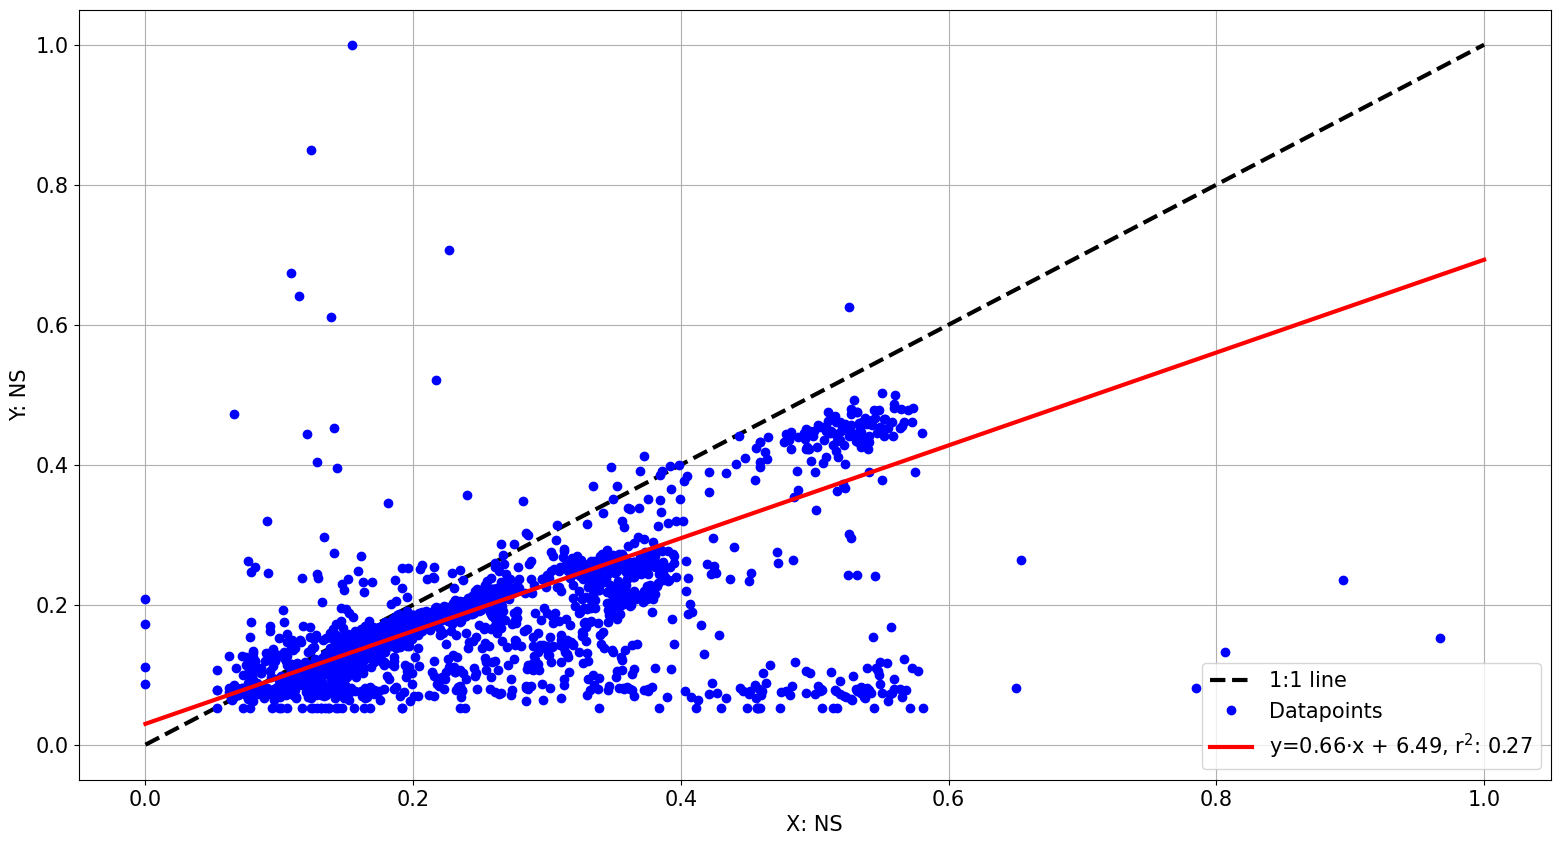

In [12]:
at.Plot_correlation(ns1,ns2,column="Median (nm)",match="nearest",tolerance="45s",intercept=False, outlier_influence=False)